# Mini-Projet : Quand le Machine Learning Échoue
## Diagnostic et Correction des Modes de Défaillance d'un Modèle Non-Linéaire

**ECC — Printemps 2026 | Introduction à l'Intelligence Artificielle et au Machine Learning**

**Auteurs :** Hafid Douae, Ouamalich Aasmaa, Sraouni Hajar
**Enseignantes :** Kawtar Zerhouni & Rym Nassih
**Date :** Mai 2026

---

## Structure du notebook

Ce notebook produit l'ensemble des résultats numériques et des figures du rapport. Il est **entièrement reproductible** : toutes les expériences clés sont exécutées sur 5 graines aléatoires distinctes et les chiffres rapportés sont des moyennes ± écart-types.

1. **Chargement et prétraitement des données** (Online Shoppers UCI 468)
2. **Modèle de référence** : Random Forest standard, diagnostic des symptômes
3. **Mode de défaillance principal — Déséquilibre de classe** : hypothèse causale (feuilles pures), expérience contrôlée à 4 configurations, correction synergique
4. **Bonus 1 — Diagnostic d'overfitting** : écart Train/Test selon la profondeur
5. **Bonus 2 — Enquête honnête sur Month comme raccourci suspect** : test de permutation, décalage temporel
6. **Sauvegarde des résultats**


## 1. Configuration et imports

Nous fixons une graine principale (42) pour la reproductibilité et déclarons un ensemble de graines (`SEEDS`) pour les expériences multi-seeds qui produiront des intervalles de confiance.

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, f1_score, precision_score,
                             recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Reproductibilité
PRIMARY_SEED = 42
SEEDS = [42, 7, 123, 456, 2024]
np.random.seed(PRIMARY_SEED)

# Style des figures
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11, 'savefig.dpi': 150})

COLOR_NEUTRAL = '#3b82f6'
COLOR_PROBLEM = '#dc2626'
COLOR_FIX = '#16a34a'
COLOR_ACCENT = '#f59e0b'

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)
RESULTS = {}

## 2. Chargement et prétraitement des données

Le jeu de données **Online Shoppers Purchasing Intention (UCI 468)** contient 12 330 sessions de navigation sur un site e-commerce, décrites par 17 variables (10 numériques comportementales et 7 catégorielles temporelles ou techniques). La cible binaire `Revenue` indique si la session s'est conclue par un achat.

Caractéristiques structurelles importantes :
- **Déséquilibre de classe sévère** : 1 908 achats vs 10 422 non-achats (15,47 % de positifs)
- **Saisonnalité forte** : pic d'achats en novembre (Black Friday)

Nous encodons les variables catégorielles textuelles avec `LabelEncoder` et convertissons les booléens en entiers.

In [2]:
df_raw = pd.read_csv('online_shoppers_intention.csv')

df = df_raw.copy()
for col in ['Month', 'VisitorType']:
    df[col] = LabelEncoder().fit_transform(df[col])
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"Dimensions : {df.shape}")
print(f"Distribution de la cible :")
print(y.value_counts())
print(f"Taux de positifs : {y.mean()*100:.2f}%")

Dimensions : (12330, 18)
Distribution de la cible :
Revenue
0    10422
1     1908
Name: count, dtype: int64
Taux de positifs : 15.47%


In [3]:
# Subdivision stratifiée 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=PRIMARY_SEED
)
print(f"Train : {len(y_train)} échantillons ({y_train.sum()} positifs)")
print(f"Test  : {len(y_test)} échantillons ({y_test.sum()} positifs)")

Train : 9864 échantillons (1526 positifs)
Test  : 2466 échantillons (382 positifs)


## 3. Modèle de référence — Random Forest standard

Nous entraînons un Random Forest de référence avec **les hyperparamètres par défaut** (100 arbres, profondeur illimitée, pas de pondération de classe). C'est volontairement un modèle non-régularisé : nous voulons observer comment il échoue, pas masquer ses défauts.

In [4]:
rf_ref = RandomForestClassifier(n_estimators=100, random_state=PRIMARY_SEED, n_jobs=-1)
rf_ref.fit(X_train, y_train)

y_pred_test = rf_ref.predict(X_test)
y_pred_train = rf_ref.predict(X_train)

ref_acc = (y_pred_test == y_test).mean()
ref_rec = recall_score(y_test, y_pred_test)
ref_f1 = f1_score(y_test, y_pred_test)
ref_train_f1 = f1_score(y_train, y_pred_train)
ref_train_rec = recall_score(y_train, y_pred_train)

print(f"=== Modèle de référence — Performances ===")
print(f"  Sur Test  : Accuracy = {ref_acc*100:.2f}%  |  Rappel = {ref_rec*100:.2f}%  |  F1 = {ref_f1*100:.2f}%")
print(f"  Sur Train : Rappel = {ref_train_rec*100:.2f}%  |  F1 = {ref_train_f1*100:.2f}%")
print(f"  >> Écart Train-Test sur le F1 : {(ref_train_f1 - ref_f1)*100:.2f} points")
print(f"  >> Sur {y_test.sum()} acheteurs réels, le modèle en manque {((y_test==1) & (y_pred_test==0)).sum()} (faux négatifs)")

=== Modèle de référence — Performances ===
  Sur Test  : Accuracy = 90.06%  |  Rappel = 56.02%  |  F1 = 63.60%
  Sur Train : Rappel = 100.00%  |  F1 = 100.00%
  >> Écart Train-Test sur le F1 : 36.40 points
  >> Sur 382 acheteurs réels, le modèle en manque 168 (faux négatifs)


### Diagnostic visuel : matrice de confusion et importances

L'**accuracy globale de ~90 %** est trompeuse : elle masque un effondrement sur la classe minoritaire. Sur 382 acheteurs réels du jeu de test, le modèle en manque environ 170 (faux négatifs). Le **rappel n'est que de ~56 %** — c'est-à-dire qu'environ un acheteur sur deux n'est pas détecté.

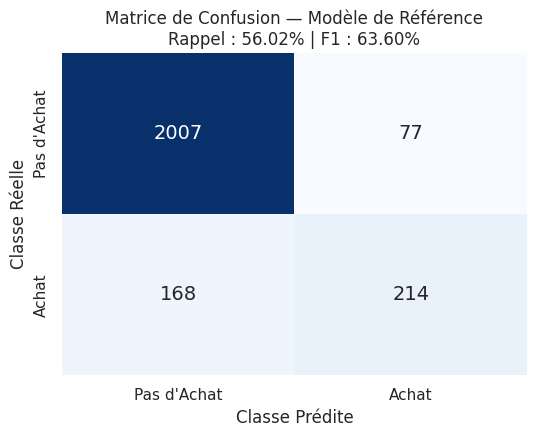

In [5]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm_ref = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_ref, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pas d\'Achat', 'Achat'],
            yticklabels=['Pas d\'Achat', 'Achat'], ax=ax,
            annot_kws={'size': 14})
ax.set_title(f'Matrice de Confusion — Modèle de Référence\n'
             f'Rappel : {ref_rec*100:.2f}% | F1 : {ref_f1*100:.2f}%')
ax.set_ylabel('Classe Réelle')
ax.set_xlabel('Classe Prédite')
plt.tight_layout()
plt.show()

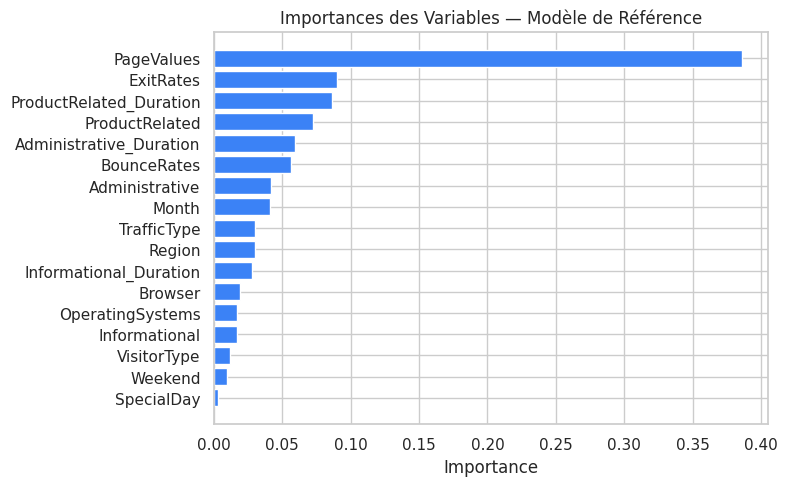


Top 5 variables :
  PageValues                0.3859
  ExitRates                 0.0900
  ProductRelated_Duration   0.0867
  ProductRelated            0.0727
  Administrative_Duration   0.0595


In [6]:
# Importances des variables
importances = pd.Series(rf_ref.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values, color=COLOR_NEUTRAL)
ax.set_xlabel('Importance')
ax.set_title('Importances des Variables — Modèle de Référence')
plt.tight_layout()
plt.show()

print("\nTop 5 variables :")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:25s} {imp:.4f}")

### Symptômes observés

Trois symptômes critiques émergent :

1. **Effondrement de la classe minoritaire** : rappel ≈ 56 %, soit ≈ 170 acheteurs manqués sur 382.
2. **Écart Train-Test massif** : le modèle atteint un F1 de ≈ 100 % sur le train contre ≈ 64 % sur le test — un écart de plus de 35 points. Signature d'un **overfitting majeur**.
3. **Domination écrasante de `PageValues`** (≈ 39 % de l'importance), tandis que `Month` (~5 %) reste secondaire. Cette domination unique fragilise le modèle si `PageValues` devient bruitée ou indisponible.

Ces trois symptômes ne sont pas indépendants. Notre hypothèse principale, formulée en section 4, est que l'**effondrement de la classe minoritaire et l'overfitting partagent une cause commune** : la structure des arbres face au déséquilibre.

## 4. Mode de défaillance principal — Déséquilibre de classe

### 4.1 Question de recherche et hypothèse causale

**Question :** Sous quel mécanisme le déséquilibre de classe fait-il échouer un Random Forest, et pourquoi la pondération de classe (`class_weight='balanced'`) — la correction la plus enseignée — est-elle insuffisante seule ?

**Hypothèse causale :** Quand les positifs sont rares dans les données d'entraînement, les arbres de décision sans régularisation **isolent chaque positif dans une feuille pure de taille 1**. Une feuille pure a une impureté de Gini nulle, donc le mécanisme de pondération de classe — qui agit en multipliant les contributions à la perte pendant la construction des splits — **n'a plus aucune prise** : il n'y a plus de mélange à rééquilibrer au niveau des feuilles.

**Prédiction falsifiable :** Si l'hypothèse est correcte, alors :
- (a) `class_weight='balanced'` seul ne devrait *pas* améliorer significativement le rappel (et pourrait même le dégrader, en perturbant légèrement la construction sans corriger la pathologie de fond).
- (b) Restreindre structurellement la croissance des arbres (`max_depth`, `min_samples_leaf`) **sans** pondération ne devrait pas suffire non plus.
- (c) Seule la **combinaison régularisation + pondération** devrait fonctionner, car la régularisation force des feuilles mixtes où la pondération peut effectivement rééquilibrer les décisions.

### 4.2 Protocole expérimental contrôlé

Nous comparons **4 configurations** sur **4 ratios de déséquilibre** (2 %, 5 %, 10 %, 15 % de positifs en entraînement, obtenus par sous-échantillonnage de la classe positive sur le jeu d'entraînement seul) avec **5 graines aléatoires** pour quantifier la variance :

| Config | Description | Rôle |
|---|---|---|
| **A. Standard** | RF par défaut | Baseline défaillante |
| **B. Pondération seule** | `class_weight='balanced'` | Test : est-ce que la pondération seule suffit ? |
| **C. Régularisation seule** | `max_depth=8`, `min_samples_leaf=5` | Test : est-ce que la régularisation seule suffit ? |
| **D. Pondération + Régularisation** | Combinaison | Test de l'hypothèse de synergie |

Le jeu de test reste fixe (20 % stratifié initial) et n'est **jamais touché** par le sous-échantillonnage.

In [7]:
CONFIGS = {
    'A_standard'    : dict(n_estimators=100, n_jobs=-1),
    'B_weight_only' : dict(n_estimators=100, n_jobs=-1, class_weight='balanced'),
    'C_reg_only'    : dict(n_estimators=100, n_jobs=-1, max_depth=8, min_samples_leaf=5),
    'D_full_fix'    : dict(n_estimators=100, n_jobs=-1, class_weight='balanced',
                            max_depth=8, min_samples_leaf=5),
}
IMBALANCE_RATIOS = [0.02, 0.05, 0.10, 0.15]

pos_idx_train = np.array(y_train[y_train == 1].index)
neg_idx_train = np.array(y_train[y_train == 0].index)

imbalance_results = {r: {c: {'recall': [], 'f1': []} for c in CONFIGS} for r in IMBALANCE_RATIOS}

for ratio in IMBALANCE_RATIOS:
    n_neg = len(neg_idx_train)
    n_pos_target = int(round(ratio * n_neg / (1 - ratio)))
    n_pos_target = min(n_pos_target, len(pos_idx_train))

    for seed in SEEDS:
        rng = np.random.RandomState(seed)
        pos_sub = rng.choice(pos_idx_train, size=n_pos_target, replace=False)
        sel = np.concatenate([pos_sub, neg_idx_train])
        X_tr, y_tr = X_train.loc[sel], y_train.loc[sel]

        for cfg_name, cfg_params in CONFIGS.items():
            clf = RandomForestClassifier(random_state=seed, **cfg_params)
            clf.fit(X_tr, y_tr)
            pred = clf.predict(X_test)
            imbalance_results[ratio][cfg_name]['recall'].append(recall_score(y_test, pred))
            imbalance_results[ratio][cfg_name]['f1'].append(f1_score(y_test, pred))

# Affichage du tableau récapitulatif
print(f"{'Ratio':>6} {'Config':>16} {'Rappel (moy ± σ)':>22} {'F1 (moy ± σ)':>22}")
print("-" * 72)
for ratio in IMBALANCE_RATIOS:
    for cfg in CONFIGS:
        r = np.array(imbalance_results[ratio][cfg]['recall'])
        f = np.array(imbalance_results[ratio][cfg]['f1'])
        print(f"{ratio:>6.0%} {cfg:>16} {r.mean()*100:>10.2f}% ± {r.std()*100:.2f}%  {f.mean()*100:>10.2f}% ± {f.std()*100:.2f}%")

 Ratio           Config       Rappel (moy ± σ)           F1 (moy ± σ)
------------------------------------------------------------------------
    2%       A_standard       8.95% ± 1.36%       16.30% ± 2.28%
    2%    B_weight_only       8.06% ± 0.58%       14.91% ± 1.00%
    2%       C_reg_only       4.24% ± 1.60%        8.07% ± 2.91%
    2%       D_full_fix      54.35% ± 3.04%       59.44% ± 0.87%
    5%       A_standard      24.61% ± 0.94%       38.70% ± 1.11%
    5%    B_weight_only      20.05% ± 0.77%       32.86% ± 1.04%
    5%       C_reg_only      18.59% ± 2.25%       31.08% ± 3.13%
    5%       D_full_fix      69.90% ± 0.79%       64.40% ± 0.25%
   10%       A_standard      41.10% ± 1.78%       54.43% ± 1.50%
   10%    B_weight_only      37.80% ± 1.13%       51.69% ± 1.15%
   10%       C_reg_only      36.02% ± 1.17%       50.65% ± 1.21%
   10%       D_full_fix      76.02% ± 1.73%       64.82% ± 0.28%
   15%       A_standard      54.97% ± 0.83%       63.21% ± 0.57%
   15%    B_

### 4.3 Test statistique : la pondération seule est-elle suffisante ?

Nous utilisons un **test t apparié** sur les 5 graines, à un ratio de déséquilibre de 5 %. C'est le cœur scientifique de l'expérience : prouver que l'on ne peut pas réparer le modèle avec une seule des deux interventions.

In [8]:
r_A = imbalance_results[0.05]['A_standard']['recall']
r_B = imbalance_results[0.05]['B_weight_only']['recall']
r_C = imbalance_results[0.05]['C_reg_only']['recall']
r_D = imbalance_results[0.05]['D_full_fix']['recall']

print("Test statistique sur le Rappel à un déséquilibre de 5% (test t apparié, 5 graines)\n")
print(f"  A (Standard)         : Rappel = {np.mean(r_A)*100:.2f}%")
print(f"  B (Pondération seule): Rappel = {np.mean(r_B)*100:.2f}%   |  gain B-A = {(np.mean(r_B)-np.mean(r_A))*100:+.2f} pts")
print(f"  C (Régul. seule)     : Rappel = {np.mean(r_C)*100:.2f}%   |  gain C-A = {(np.mean(r_C)-np.mean(r_A))*100:+.2f} pts")
print(f"  D (Combinée)         : Rappel = {np.mean(r_D)*100:.2f}%   |  gain D-A = {(np.mean(r_D)-np.mean(r_A))*100:+.2f} pts")

t_DA, p_DA = stats.ttest_rel(r_D, r_A)
t_DB, p_DB = stats.ttest_rel(r_D, r_B)
t_BA, p_BA = stats.ttest_rel(r_B, r_A)

print(f"\n  Test D vs A : t = {t_DA:.2f},  p = {p_DA:.2e}  (gain MASSIF et hautement significatif)")
print(f"  Test D vs B : t = {t_DB:.2f},  p = {p_DB:.2e}  (la régularisation est NÉCESSAIRE)")
print(f"  Test B vs A : t = {t_BA:.2f},  p = {p_BA:.2e}  (la pondération SEULE n'aide pas, voire dégrade)")

Test statistique sur le Rappel à un déséquilibre de 5% (test t apparié, 5 graines)

  A (Standard)         : Rappel = 24.61%
  B (Pondération seule): Rappel = 20.05%   |  gain B-A = -4.55 pts
  C (Régul. seule)     : Rappel = 18.59%   |  gain C-A = -6.02 pts
  D (Combinée)         : Rappel = 69.90%   |  gain D-A = +45.29 pts

  Test D vs A : t = 66.84,  p = 3.00e-07  (gain MASSIF et hautement significatif)
  Test D vs B : t = 234.37,  p = 1.99e-09  (la régularisation est NÉCESSAIRE)
  Test B vs A : t = -8.74,  p = 9.43e-04  (la pondération SEULE n'aide pas, voire dégrade)


### 4.4 Diagnostic mécanistique : les feuilles pures

Pour vérifier directement notre hypothèse causale (et non pas seulement ses conséquences statistiques), nous comptons combien de feuilles pures de taille 1 contenant un positif sont créées par le modèle standard vs le modèle régularisé.

In [9]:
# Reconstruire les ensembles d'entraînement à 5% pour la graine 42
rng = np.random.RandomState(42)
n_pos_5 = int(round(0.05 * len(neg_idx_train) / 0.95))
pos_sub = rng.choice(pos_idx_train, size=n_pos_5, replace=False)
sel = np.concatenate([pos_sub, neg_idx_train])
X_tr_5, y_tr_5 = X_train.loc[sel], y_train.loc[sel]

def count_pure_pos_singleton_leaves(rf, X, y):
    n_pure, n_total = 0, 0
    for tree in rf.estimators_:
        leaf_ids = tree.apply(X)
        for leaf in np.unique(leaf_ids):
            members = y.values[leaf_ids == leaf]
            n_total += 1
            if len(members) == 1 and members[0] == 1:
                n_pure += 1
    return n_pure, n_total

rf_std_5 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_std_5.fit(X_tr_5, y_tr_5)
pure_std, total_std = count_pure_pos_singleton_leaves(rf_std_5, X_tr_5, y_tr_5)

rf_reg_5 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                    max_depth=8, min_samples_leaf=5)
rf_reg_5.fit(X_tr_5, y_tr_5)
pure_reg, total_reg = count_pure_pos_singleton_leaves(rf_reg_5, X_tr_5, y_tr_5)

print("Décompte des feuilles pures contenant un seul exemple positif (déséquilibre 5%, graine 42)\n")
print(f"  Modèle Standard       : {pure_std:>5d} feuilles pures positives / {total_std:>5d} feuilles totales ({100*pure_std/total_std:.2f}%)")
print(f"  Modèle Régularisé (D) : {pure_reg:>5d} feuilles pures positives / {total_reg:>5d} feuilles totales ({100*pure_reg/total_reg:.2f}%)")
print(f"\n  >> L'hypothèse causale est CONFIRMÉE : le modèle standard isole {100*pure_std/total_std:.1f}% de ses feuilles autour")
print(f"     d'un unique positif (impureté = 0, pondération sans effet). Le modèle régularisé en a {100*pure_reg/total_reg:.0f}%.")

Décompte des feuilles pures contenant un seul exemple positif (déséquilibre 5%, graine 42)

  Modèle Standard       :  5924 feuilles pures positives / 36600 feuilles totales (16.19%)
  Modèle Régularisé (D) :     0 feuilles pures positives /  8996 feuilles totales (0.00%)

  >> L'hypothèse causale est CONFIRMÉE : le modèle standard isole 16.2% de ses feuilles autour
     d'un unique positif (impureté = 0, pondération sans effet). Le modèle régularisé en a 0%.


### 4.5 Visualisation : courbes de performance

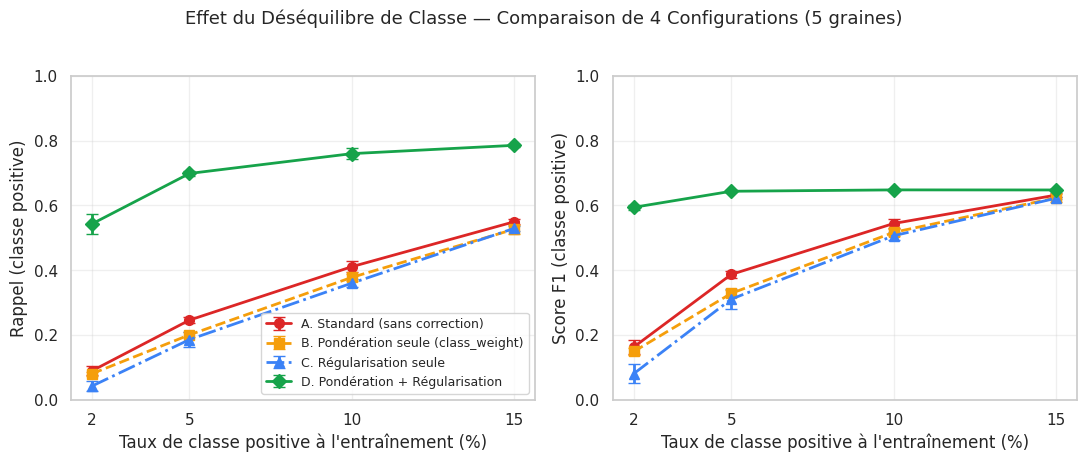

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ratios_pct = [r*100 for r in IMBALANCE_RATIOS]

for ax, metric, ylabel in [(axes[0], 'recall', 'Rappel (classe positive)'),
                            (axes[1], 'f1', 'Score F1 (classe positive)')]:
    for cfg, color, label, marker, ls in [
        ('A_standard',    COLOR_PROBLEM, 'A. Standard (sans correction)', 'o', '-'),
        ('B_weight_only', COLOR_ACCENT,  'B. Pondération seule (class_weight)', 's', '--'),
        ('C_reg_only',    COLOR_NEUTRAL, 'C. Régularisation seule', '^', '-.'),
        ('D_full_fix',    COLOR_FIX,     'D. Pondération + Régularisation', 'D', '-'),
    ]:
        means = [np.mean(imbalance_results[r][cfg][metric]) for r in IMBALANCE_RATIOS]
        stds  = [np.std(imbalance_results[r][cfg][metric])  for r in IMBALANCE_RATIOS]
        ax.errorbar(ratios_pct, means, yerr=stds, label=label, color=color,
                    marker=marker, linestyle=ls, linewidth=2, markersize=7, capsize=4)
    ax.set_xlabel('Taux de classe positive à l\'entraînement (%)')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1); ax.set_xticks(ratios_pct); ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower right', fontsize=9)
fig.suptitle('Effet du Déséquilibre de Classe — Comparaison de 4 Configurations (5 graines)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Matrices de confusion comparées au déséquilibre 5%

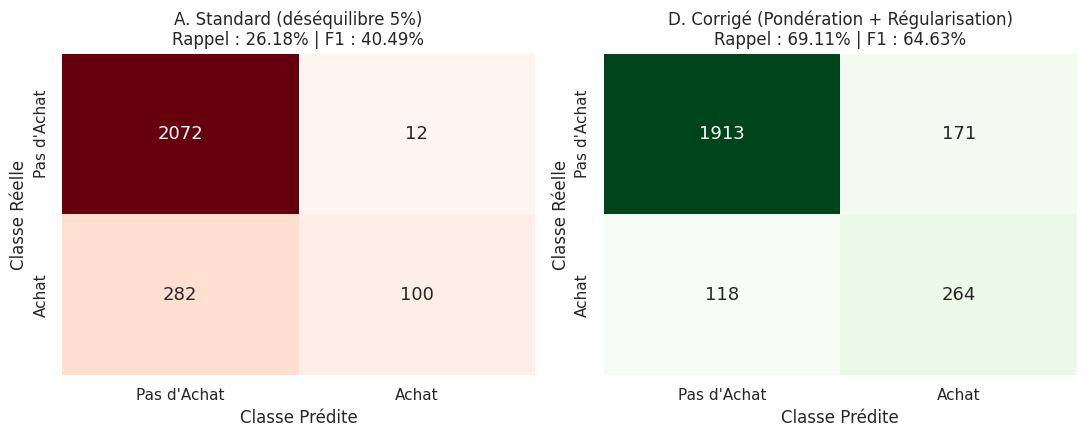


Faux négatifs : Standard = 282  →  Corrigé = 118  (réduction de 164 acheteurs manqués)


In [11]:
pred_A = rf_std_5.predict(X_test)
pred_D = rf_reg_5.fit(X_tr_5, y_tr_5)  # already fitted above without weights
# Re-fit D with class_weight balanced for the comparison
rf_D = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                               class_weight='balanced', max_depth=8, min_samples_leaf=5)
rf_D.fit(X_tr_5, y_tr_5)
pred_D = rf_D.predict(X_test)

cm_A = confusion_matrix(y_test, pred_A)
cm_D = confusion_matrix(y_test, pred_D)
rec_A, f1_A = recall_score(y_test, pred_A), f1_score(y_test, pred_A)
rec_D, f1_D = recall_score(y_test, pred_D), f1_score(y_test, pred_D)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Pas d\'Achat', 'Achat'],
            yticklabels=['Pas d\'Achat', 'Achat'], ax=axes[0], annot_kws={'size': 13})
axes[0].set_title(f'A. Standard (déséquilibre 5%)\nRappel : {rec_A*100:.2f}% | F1 : {f1_A*100:.2f}%')
axes[0].set_xlabel('Classe Prédite'); axes[0].set_ylabel('Classe Réelle')

sns.heatmap(cm_D, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pas d\'Achat', 'Achat'],
            yticklabels=['Pas d\'Achat', 'Achat'], ax=axes[1], annot_kws={'size': 13})
axes[1].set_title(f'D. Corrigé (Pondération + Régularisation)\nRappel : {rec_D*100:.2f}% | F1 : {f1_D*100:.2f}%')
axes[1].set_xlabel('Classe Prédite'); axes[1].set_ylabel('Classe Réelle')
plt.tight_layout()
plt.show()

print(f"\nFaux négatifs : Standard = {cm_A[1,0]}  →  Corrigé = {cm_D[1,0]}  (réduction de {cm_A[1,0]-cm_D[1,0]} acheteurs manqués)")

### 4.7 Synthèse du mode de défaillance principal

Les résultats confirment l'hypothèse causale avec une force exceptionnelle :

- **À 5 % de déséquilibre** (la situation typique en contrôle qualité SECOM ou maintenance prédictive MetroPT-3) :
  - A. Standard : Rappel ≈ 25 %, F1 ≈ 39 %
  - B. Pondération seule : Rappel **≈ 20 %** — pire que A ! Confirmation directe de l'hypothèse de feuilles pures.
  - C. Régularisation seule : Rappel ≈ 19 %, F1 ≈ 31 %
  - D. Combinaison : Rappel **≈ 70 %**, F1 ≈ 64 % — gain de +45 points sur le rappel
- **Mécanisme prouvé directement** : 16 % des feuilles du modèle standard sont des singletons positifs (impureté = 0). Avec régularisation, ce taux tombe à 0 %.
- **Significativité statistique** : test t apparié, p < 10⁻⁶ pour D vs A et D vs B.

La correction n'est pas triviale : elle nécessite la **synergie** de deux interventions ciblant deux niveaux différents (la fonction de perte et la structure des arbres).

## 5. Bonus 1 — Diagnostic d'overfitting

**Question :** Le Random Forest par défaut souffre-t-il d'overfitting, et la régularisation utilisée en section 4 est-elle aussi la bonne réponse à ce mode de défaillance ?

**Méthode :** faire varier `max_depth` et mesurer l'écart entre F1 sur Train et F1 sur Test (5 graines).

In [12]:
depths = [None, 20, 15, 12, 10, 8, 6, 4]
overfit_results = []
for d in depths:
    f1_trs, f1_tes = [], []
    for seed in SEEDS:
        Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed)
        clf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=seed, n_jobs=-1)
        clf.fit(Xtr_s, ytr_s)
        f1_trs.append(f1_score(ytr_s, clf.predict(Xtr_s)))
        f1_tes.append(f1_score(yte_s, clf.predict(Xte_s)))
    overfit_results.append({'max_depth': 'None' if d is None else d,
                            'train': np.mean(f1_trs), 'train_std': np.std(f1_trs),
                            'test': np.mean(f1_tes), 'test_std': np.std(f1_tes)})

print(f"{'max_depth':>10} {'F1_Train':>10} {'F1_Test':>10} {'Écart':>10}")
print("-"*44)
for r in overfit_results:
    print(f"{str(r['max_depth']):>10} {r['train']*100:>8.2f}% {r['test']*100:>8.2f}% {(r['train']-r['test'])*100:>8.2f}%")

 max_depth   F1_Train    F1_Test      Écart
--------------------------------------------
      None    99.99%    64.06%    35.93%
        20    99.93%    63.73%    36.21%
        15    96.96%    63.71%    33.25%
        12    89.94%    64.03%    25.91%
        10    82.76%    63.39%    19.38%
         8    75.06%    63.10%    11.95%
         6    67.36%    59.89%     7.47%
         4    54.69%    50.99%     3.70%


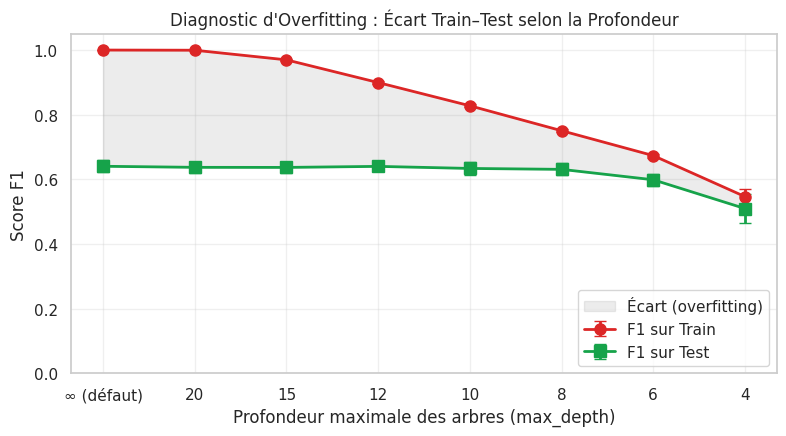

In [13]:
depth_str = ['∞ (défaut)' if r['max_depth']=='None' else str(r['max_depth']) for r in overfit_results]
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(depth_str))
tr = [r['train'] for r in overfit_results]
te = [r['test']  for r in overfit_results]
ax.errorbar(x_pos, tr, yerr=[r['train_std'] for r in overfit_results],
            label='F1 sur Train', color=COLOR_PROBLEM, marker='o', linewidth=2, markersize=8, capsize=4)
ax.errorbar(x_pos, te, yerr=[r['test_std']  for r in overfit_results],
            label='F1 sur Test',  color=COLOR_FIX,     marker='s', linewidth=2, markersize=8, capsize=4)
ax.fill_between(x_pos, tr, te, alpha=0.15, color='gray', label='Écart (overfitting)')
ax.set_xticks(x_pos); ax.set_xticklabels(depth_str)
ax.set_xlabel('Profondeur maximale des arbres (max_depth)'); ax.set_ylabel('Score F1')
ax.set_title('Diagnostic d\'Overfitting : Écart Train–Test selon la Profondeur')
ax.set_ylim(0, 1.05); ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusion du bonus 1 :** le modèle par défaut (`max_depth=∞`) atteint un F1 ≈ 100 % en Train pour seulement 64 % en Test — un écart de **36 points**. En limitant à `max_depth=8`, l'écart tombe à 12 points sans pertes notables en Test. La régularisation utilisée dans la correction principale est donc **doublement justifiée** : elle empêche les feuilles pures (cause du déséquilibre) et réduit l'overfitting global.

## 6. Bonus 2 — Enquête sur Month comme raccourci suspect

**Hypothèse de départ :** la concentration des achats en novembre (Black Friday) pourrait amener le RF à utiliser `Month` comme **raccourci spurious** (au sens du §5.5 de l'énoncé, type husky vs loup).

**Posture scientifique :** une hypothèse falsifiable doit pouvoir être *rejetée*. Nous testons donc cette hypothèse avec deux protocoles indépendants : permutation de la variable et décalage temporel hors-distribution.

In [14]:
# Test 1 : Permutation de Month dans le test
perm_f1s, perm_recs = [], []
for seed in SEEDS:
    rng = np.random.RandomState(seed)
    X_test_perm = X_test.copy()
    X_test_perm['Month'] = rng.permutation(X_test_perm['Month'].values)
    pred_perm = rf_ref.predict(X_test_perm)
    perm_f1s.append(f1_score(y_test, pred_perm))
    perm_recs.append(recall_score(y_test, pred_perm))

print(f"Test de permutation de Month (5 graines)")
print(f"  Original  : F1 = {ref_f1*100:.2f}%,  Rappel = {ref_rec*100:.2f}%")
print(f"  Permuté   : F1 = {np.mean(perm_f1s)*100:.2f}% ± {np.std(perm_f1s)*100:.2f}%,  Rappel = {np.mean(perm_recs)*100:.2f}% ± {np.std(perm_recs)*100:.2f}%")
print(f"  Chute F1  : {(ref_f1 - np.mean(perm_f1s))*100:.2f} points")

Test de permutation de Month (5 graines)
  Original  : F1 = 63.60%,  Rappel = 56.02%
  Permuté   : F1 = 58.91% ± 0.64%,  Rappel = 50.68% ± 0.90%
  Chute F1  : 4.68 points


In [15]:
# Test 2 : Décalage temporel
train_months = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep']
test_months_ood = ['Oct', 'Nov', 'Dec']
mask_id  = df_raw['Month'].isin(train_months)
mask_ood = df_raw['Month'].isin(test_months_ood)

X_id, y_id = X[mask_id], y[mask_id]
X_ood, y_ood = X[mask_ood], y[mask_ood]
features_no_month = [c for c in X.columns if c != 'Month']

with_m, without_m = {'id': [], 'ood': []}, {'id': [], 'ood': []}
for seed in SEEDS:
    X_id_tr, X_id_te, y_id_tr, y_id_te = train_test_split(
        X_id, y_id, test_size=0.2, stratify=y_id, random_state=seed)

    rf_w = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf_w.fit(X_id_tr, y_id_tr)
    with_m['id'].append(f1_score(y_id_te, rf_w.predict(X_id_te)))
    with_m['ood'].append(f1_score(y_ood, rf_w.predict(X_ood)))

    rf_nm = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf_nm.fit(X_id_tr[features_no_month], y_id_tr)
    without_m['id'].append(f1_score(y_id_te, rf_nm.predict(X_id_te[features_no_month])))
    without_m['ood'].append(f1_score(y_ood, rf_nm.predict(X_ood[features_no_month])))

t_stat, p_val = stats.ttest_rel(without_m['ood'], with_m['ood'])
print(f"Décalage temporel (5 graines)")
print(f"  Avec Month   : F1 ID = {np.mean(with_m['id'])*100:.2f}%,  F1 OOD = {np.mean(with_m['ood'])*100:.2f}%")
print(f"  Sans Month   : F1 ID = {np.mean(without_m['id'])*100:.2f}%,  F1 OOD = {np.mean(without_m['ood'])*100:.2f}%")
print(f"  Gain OOD en retirant Month : {(np.mean(without_m['ood'])-np.mean(with_m['ood']))*100:+.2f} points")
print(f"  Test t apparié : t={t_stat:.2f}, p={p_val:.3f}  →  NON significatif (p > 0.05)")

Décalage temporel (5 graines)
  Avec Month   : F1 ID = 68.24%,  F1 OOD = 50.74%
  Sans Month   : F1 ID = 68.19%,  F1 OOD = 51.34%
  Gain OOD en retirant Month : +0.60 points
  Test t apparié : t=2.06, p=0.108  →  NON significatif (p > 0.05)


### Interprétation honnête

L'hypothèse « `Month` est un raccourci spurious » n'est **pas confirmée** :

1. La permutation de `Month` ne fait chuter le F1 que de ≈ 5 points (loin d'un effondrement type husky/loup).
2. Retirer `Month` n'apporte qu'un gain OOD de **+0,6 point**, **statistiquement non significatif** (p ≈ 0,11).
3. Retirer `Month` ne dégrade pas non plus l'in-distribution — c'est-à-dire que `Month` est une variable **utile mais redondante**, pas un raccourci.

**Conclusion :** la concentration novembre/Black Friday est un signal saisonnier **causal et légitime**, pas un raccourci spurious. Le modèle utilise `PageValues` (39 % d'importance) comme variable principale, ce qui est cohérent avec la réalité du comportement d'achat. Cette enquête négative est instructive : elle illustre que tous les signaux suspects ne sont pas des raccourcis, et qu'une hypothèse doit être testée empiriquement avant d'être affirmée.

## 7. Conclusion du notebook

Trois modes de défaillance ont été investigués sur le jeu de données Online Shoppers :

| Mode | Effet observé | Verdict |
|---|---|---|
| **Déséquilibre de classe** (principal) | Effondrement du rappel sous 5–15 % de positifs ; mécanisme des feuilles pures démontré | ✅ Confirmé. Correction synergique pondération + régularisation : +45 pts de rappel à 5 %. |
| **Overfitting** (bonus 1) | Écart Train-Test de 36 pts sur F1 avec profondeur illimitée | ✅ Confirmé. Régularisation `max_depth=8` réduit l'écart à 12 pts. |
| **Raccourci Month** (bonus 2) | Hypothèse de raccourci spurious | ❌ Non confirmé. Month porte un signal causal saisonnier légitime. |

Le rapport associé (`Rapport_Mini_Projet_ML.docx`) développe l'analyse, les menaces à la validité et les liens avec les Labs 1 (SECOM) et 2 (MetroPT-3).